# 05 - Long-Horizon Inertia Experiments

This notebook is a focused follow-up to [04_lstm_experiments_10032026.ipynb](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/04_lstm_experiments_10032026.ipynb).

The goal is to test whether inertia-aware variables become more useful when the forecast target is moved further ahead or aggregated over a short energy window.

Compared with the earlier version of this notebook, this refresh does four things:

- cleans up the summary/export logic so only valid target rows are reported,
- adds a simple persistence baseline directly into the run log,
- expands the horizon set to `1h`, `4h`, `8h`, cumulative `4h`, and cumulative `8h`,
- and expands the illustrative building set while keeping the notebook readable.

The main comparison is still the temporal LSTM family, but now with four explicit modes:

- `M0`: base temporal core (`heat_obs + weather + calendar`)
- `M1`: `M0 +` weather-memory feature
- `M2`: `M0 +` system / inertia block
- `M3`: `M2 +` weather-memory feature

This makes it easier to separate the effect of weather memory from the effect of the system-state / inertia variables.


In [1]:
# Section 0 - Imports, configuration, and quieter runtime setup

from __future__ import annotations

from pathlib import Path
import os
import time
from typing import Dict, List, Tuple

# Keep TensorFlow C++ logs out of the notebook unless something is truly fatal.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ.setdefault('MPLCONFIGDIR', '/tmp/codex-mplconfig')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
    absl.logging.set_stderrthreshold('error')
except Exception:
    pass

tf.get_logger().setLevel('ERROR')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

cwd = Path.cwd()
if cwd.name == 'thesis-project':
    PROJECT_ROOT = cwd
elif (cwd / 'thesis-project').exists():
    PROJECT_ROOT = cwd / 'thesis-project'
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / 'data'
FEATURE_DIR = DATA_DIR / 'features'
CLEAN_DIR = DATA_DIR / 'clean'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_METADATA_FILE = FEATURE_DIR / 'feature_metadata.csv'
PORTFOLIO_COVERAGE_FILE = FEATURE_DIR / 'portfolio_coverage.csv'
CAMPUS_PROXY_FILE = CLEAN_DIR / 'campus_building_features_for_models.csv'

RUN_BUILDINGS = ['U05', 'U06', 'LIB', 'U02B', 'SOC', 'U03']
RUN_MODES = ['M0', 'M1', 'M2', 'M3']
RUN_SEEDS = [42]
LOOKBACK_HOURS = 24
TRAIN_END = pd.Timestamp('2023-12-31 23:00:00')
TEST_START = TRAIN_END + pd.Timedelta(hours=1)
FIT_VALIDATION_FRACTION = 0.10
BATCH_SIZE = 64
EPOCHS = 35
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 1e-3

TARGET_SPECS = [
    {'target_name': 'target_point_h1', 'target_family': 'point', 'horizon_hours': 1},
    {'target_name': 'target_point_h4', 'target_family': 'point', 'horizon_hours': 4},
    {'target_name': 'target_point_h8', 'target_family': 'point', 'horizon_hours': 8},
    {'target_name': 'target_cum_h4', 'target_family': 'cumulative', 'horizon_hours': 4},
    {'target_name': 'target_cum_h8', 'target_family': 'cumulative', 'horizon_hours': 8},
]

RUN_LONG_HORIZON_NOW = True
RUN_SMOKE_TEST_NOW = False
SMOKE_BUILDING = 'U05'
SMOKE_TARGET = 'target_cum_h8'
SMOKE_MODE = 'M2'
SMOKE_SEED = 42
SMOKE_EPOCHS = 1

PLOT_TRACE_NOW = False
TRACE_BUILDING = 'U05'
TRACE_TARGET = 'target_cum_h8'
TRACE_PLOT_START = '2024-01-08'
TRACE_PLOT_END = '2024-01-15'

RUNLOG_FILE = RESULTS_DIR / 'long_horizon_inertia_run_log.csv'
CHECKPOINT_FILE = RESULTS_DIR / 'long_horizon_inertia_run_log_checkpoint.csv'
SUMMARY_FILE = RESULTS_DIR / 'long_horizon_inertia_summary.csv'
GAIN_FILE = RESULTS_DIR / 'long_horizon_inertia_gain_vs_M0.csv'
TRACE_FILE = RESULTS_DIR / 'long_horizon_inertia_trace_predictions.csv'

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

print('Project root :', PROJECT_ROOT)
print('Buildings    :', RUN_BUILDINGS)
print('Modes        :', RUN_MODES)
print('Targets      :', [t['target_name'] for t in TARGET_SPECS])
print('Seeds        :', RUN_SEEDS)
print('Total fits   :', len(RUN_BUILDINGS) * len(RUN_MODES) * len(TARGET_SPECS) * len(RUN_SEEDS))
print('FIT_VALIDATION_FRACTION =', FIT_VALIDATION_FRACTION)
print('RUN_LONG_HORIZON_NOW =', RUN_LONG_HORIZON_NOW)


Project root : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Buildings    : ['U05', 'U06', 'LIB', 'U02B', 'SOC', 'U03']
Modes        : ['M0', 'M1', 'M2', 'M3']
Targets      : ['target_point_h1', 'target_point_h4', 'target_point_h8', 'target_cum_h4', 'target_cum_h8']
Seeds        : [42]
Total fits   : 120
FIT_VALIDATION_FRACTION = 0.1
RUN_LONG_HORIZON_NOW = True


## Section 1 - Explicit feature design

Feature choices remain explicit inside this notebook.

- `M0`: recent heat, weather, and calendar
- `M1`: `M0 +` 24-hour temperature memory
- `M2`: `M0 +` system-state / inertia block
- `M3`: `M2 +` 24-hour temperature memory

This lets us test whether improvements come from weather-memory alone or from the system / inertia variables.


In [2]:
# Section 1 - Load metadata and define explicit feature blocks

feature_meta = pd.read_csv(FEATURE_METADATA_FILE)
portfolio_cov = pd.read_csv(PORTFOLIO_COVERAGE_FILE, parse_dates=['first_obs', 'last_obs'])
proxy_df = pd.read_csv(CAMPUS_PROXY_FILE)

LSTM_BASE_TEMPORAL_FEATURES = [
    'feat_heat_obs',
    'feat_outdoor_temp_c',
    'feat_wind_ms',
    'feat_solar_irradiance_wm2',
    'feat_hour_sin',
    'feat_hour_cos',
    'feat_dow_sin',
    'feat_dow_cos',
]

LSTM_WEATHER_MEMORY_FEATURES = [
    'feat_temp_roll24h',
]

LSTM_SYSTEM_DYNAMIC_FEATURES = [
    'feat_space_heat_active',
    'feat_space_deltaT_c',
    'feat_space_low_deltaT_flag',
    'feat_vent_heat_active',
    'feat_vent_deltaT_c',
    'feat_vent_low_deltaT_flag',
]

ALL_TEMPORAL_FEATURES = (
    LSTM_BASE_TEMPORAL_FEATURES
    + LSTM_WEATHER_MEMORY_FEATURES
    + LSTM_SYSTEM_DYNAMIC_FEATURES
)

MODE_FEATURES = {
    'M0': LSTM_BASE_TEMPORAL_FEATURES.copy(),
    'M1': LSTM_BASE_TEMPORAL_FEATURES + LSTM_WEATHER_MEMORY_FEATURES,
    'M2': LSTM_BASE_TEMPORAL_FEATURES + LSTM_SYSTEM_DYNAMIC_FEATURES,
    'M3': LSTM_BASE_TEMPORAL_FEATURES + LSTM_SYSTEM_DYNAMIC_FEATURES + LSTM_WEATHER_MEMORY_FEATURES,
}

for mode, cols in MODE_FEATURES.items():
    seen = set()
    MODE_FEATURES[mode] = [c for c in cols if not (c in seen or seen.add(c))]

feature_paths = feature_meta.set_index('building')['path_setA'].to_dict()
missing_buildings = [b for b in RUN_BUILDINGS if b not in feature_paths]
if missing_buildings:
    raise ValueError(f'Missing feature metadata for buildings: {missing_buildings}')

print('M0 features:', MODE_FEATURES['M0'])
print('M1 features:', MODE_FEATURES['M1'])
print('M2 features:', MODE_FEATURES['M2'])
print('M3 features:', MODE_FEATURES['M3'])
print()
print('Illustrative building proxies:')
proxy_view = proxy_df.loc[proxy_df['building_abv'].isin(RUN_BUILDINGS), [
    'building_abv', 'vent_class', 'energy_class', 'ac24', 'night_day_ratio', 'n_vent_points'
]].sort_values('building_abv')
print(proxy_view.to_string(index=False))


M0 features: ['feat_heat_obs', 'feat_outdoor_temp_c', 'feat_wind_ms', 'feat_solar_irradiance_wm2', 'feat_hour_sin', 'feat_hour_cos', 'feat_dow_sin', 'feat_dow_cos']
M1 features: ['feat_heat_obs', 'feat_outdoor_temp_c', 'feat_wind_ms', 'feat_solar_irradiance_wm2', 'feat_hour_sin', 'feat_hour_cos', 'feat_dow_sin', 'feat_dow_cos', 'feat_temp_roll24h']
M2 features: ['feat_heat_obs', 'feat_outdoor_temp_c', 'feat_wind_ms', 'feat_solar_irradiance_wm2', 'feat_hour_sin', 'feat_hour_cos', 'feat_dow_sin', 'feat_dow_cos', 'feat_space_heat_active', 'feat_space_deltaT_c', 'feat_space_low_deltaT_flag', 'feat_vent_heat_active', 'feat_vent_deltaT_c', 'feat_vent_low_deltaT_flag']
M3 features: ['feat_heat_obs', 'feat_outdoor_temp_c', 'feat_wind_ms', 'feat_solar_irradiance_wm2', 'feat_hour_sin', 'feat_hour_cos', 'feat_dow_sin', 'feat_dow_cos', 'feat_space_heat_active', 'feat_space_deltaT_c', 'feat_space_low_deltaT_flag', 'feat_vent_heat_active', 'feat_vent_deltaT_c', 'feat_vent_low_deltaT_flag', 'feat_tem

## Section 2 - Load the selected buildings and build longer-horizon targets

Target definitions:

- `target_point_h1`: next hour heat
- `target_point_h4`: heat 4 hours ahead
- `target_point_h8`: heat 8 hours ahead
- `target_cum_h4`: sum of the next 4 hours
- `target_cum_h8`: sum of the next 8 hours

This notebook also computes a simple persistence baseline on the same sequence windows so the final run log can be interpreted directly against a naive benchmark.


There is no longer a separate fixed autumn validation season. The model is trained on the full 2023 history, and a small **chronological** fit-time validation subset is taken from the tail of the training sequences only for optimisation callbacks. This keeps the final temporal split simple: full 2023 for training, full 2024 for testing.

Important split detail: for `h>1` and cumulative targets, the **training issue times are truncated by horizon** so that no training target reaches into 2024. This prevents leakage across the year boundary.

In [3]:
# Section 2 - Load feature frames, build targets, define splits


def load_feature_frame(path_str: str) -> pd.DataFrame:
    csv_path = PROJECT_ROOT / path_str
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)
    return pd.read_csv(csv_path, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)


def add_long_horizon_targets(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    heat = out['heat_kwh'].astype(float)

    out['target_point_h1'] = heat
    out['target_point_h4'] = heat.shift(-3)
    out['target_point_h8'] = heat.shift(-7)
    out['target_cum_h4'] = sum(heat.shift(-i) for i in range(4))
    out['target_cum_h8'] = sum(heat.shift(-i) for i in range(8))
    return out


def train_issue_end_for_target(horizon_hours: int) -> pd.Timestamp:
    return TRAIN_END - pd.Timedelta(hours=horizon_hours - 1)


features_by_building: Dict[str, pd.DataFrame] = {}
split_masks: Dict[str, Dict[str, Dict[str, np.ndarray]]] = {}
coverage_rows = []

for bldg in RUN_BUILDINGS:
    df = load_feature_frame(feature_paths[bldg])
    df = add_long_horizon_targets(df)

    missing_cols = sorted(set(ALL_TEMPORAL_FEATURES + ['heat_kwh']) - set(df.columns))
    if missing_cols:
        raise ValueError(f'{bldg} is missing required columns: {missing_cols}')

    dt = pd.to_datetime(df['datetime'])
    base_test_mask = dt >= TEST_START

    features_by_building[bldg] = df
    split_masks[bldg] = {}

    row = {
        'building': bldg,
        'rows_total': len(df),
        'rows_test_base': int(base_test_mask.sum()),
    }
    for spec in TARGET_SPECS:
        target_name = spec['target_name']
        horizon_hours = int(spec['horizon_hours'])
        train_issue_end = train_issue_end_for_target(horizon_hours)
        train_mask = dt <= train_issue_end
        split_masks[bldg][target_name] = {
            'train': train_mask.values,
            'test': base_test_mask.values,
            'train_issue_end': train_issue_end,
        }
        row[f"{target_name}_issue_train_rows"] = int(train_mask.sum())
        row[f"{target_name}_nonnull_train"] = int(df.loc[train_mask, target_name].notna().sum())
        row[f"{target_name}_nonnull_test"] = int(df.loc[base_test_mask, target_name].notna().sum())
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows).sort_values('building').reset_index(drop=True)
print(coverage_df.to_string(index=False))


building  rows_total  rows_test_base  target_point_h1_issue_train_rows  target_point_h1_nonnull_train  target_point_h1_nonnull_test  target_point_h4_issue_train_rows  target_point_h4_nonnull_train  target_point_h4_nonnull_test  target_point_h8_issue_train_rows  target_point_h8_nonnull_train  target_point_h8_nonnull_test  target_cum_h4_issue_train_rows  target_cum_h4_nonnull_train  target_cum_h4_nonnull_test  target_cum_h8_issue_train_rows  target_cum_h8_nonnull_train  target_cum_h8_nonnull_test
     LIB       22954            8784                             14170                          14170                          8784                             14167                          14167                          8781                             14163                          14163                          8777                           14167                        14167                        8781                           14163                        14163                        8777


## Section 3 - Scalers, sequence builder, baseline, and model helpers

A separate target scaler is fit for every `building x target_name` pair.

The notebook also computes a simple persistence baseline on the same sequence windows:

- point targets: predict the last observed heat
- cumulative targets: predict `horizon_hours x last observed heat`


**Validation note**: the fit-time validation split is chronological, using the last fraction of the training sequences rather than random sampling.

**Metric note**: a guarded `MAPE` is retained in the run log for completeness, but it is **not** a stable primary metric for these heat targets. For interpretation, use `WAPE`, `MAE`, `RMSE`, and `R2` first.

In [4]:
# Section 3 - Preprocessors and helper functions


def set_all_seeds(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def make_optimizer():
    try:
        return tf.keras.optimizers.legacy.Adam(learning_rate=LEARNING_RATE)
    except Exception:
        return keras.optimizers.Adam(learning_rate=LEARNING_RATE)


temporal_scalers: Dict[str, StandardScaler] = {}
target_scalers: Dict[Tuple[str, str], StandardScaler] = {}

for bldg, df in features_by_building.items():
    feature_train_mask = pd.to_datetime(df['datetime']) <= TRAIN_END

    scaler_X = StandardScaler()
    scaler_X.fit(df.loc[feature_train_mask, ALL_TEMPORAL_FEATURES].values)
    temporal_scalers[bldg] = scaler_X

    for spec in TARGET_SPECS:
        target_name = spec['target_name']
        target_train_mask = split_masks[bldg][target_name]['train']
        y_train = df.loc[target_train_mask, [target_name]].dropna().values
        if len(y_train) == 0:
            continue
        scaler_y = StandardScaler()
        scaler_y.fit(y_train)
        target_scalers[(bldg, target_name)] = scaler_y


def build_sequences(
    df_scaled: pd.DataFrame,
    dynamic_cols: List[str],
    target_col: str,
    split_mask: np.ndarray,
    lookback: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X_list, y_list, ts_list = [], [], []
    mask = np.asarray(split_mask, dtype=bool)

    for end_idx in range(lookback, len(df_scaled)):
        if not mask[end_idx]:
            continue
        start_idx = end_idx - lookback
        if not mask[start_idx:end_idx].all():
            continue

        window = df_scaled.iloc[start_idx:end_idx]
        target_val = df_scaled.iloc[end_idx][target_col]
        if window[dynamic_cols].isna().any().any() or pd.isna(target_val):
            continue

        X_list.append(window[dynamic_cols].values.astype('float32'))
        y_list.append(float(target_val))
        ts_list.append(pd.Timestamp(df_scaled.iloc[end_idx]['datetime']))

    if not X_list:
        return (
            np.empty((0, lookback, len(dynamic_cols)), dtype='float32'),
            np.empty((0,), dtype='float32'),
            np.empty((0,), dtype='datetime64[ns]'),
        )

    return (
        np.stack(X_list, axis=0),
        np.array(y_list, dtype='float32'),
        np.array(ts_list, dtype='datetime64[ns]'),
    )




def make_internal_fit_split(X: np.ndarray, y: np.ndarray, frac: float, seed: int):
    n = X.shape[0]
    if n == 0:
        return X, y, X, y
    if frac <= 0 or n < 50:
        return X, y, np.empty((0,) + X.shape[1:], dtype=X.dtype), np.empty((0,), dtype=y.dtype)

    n_val = max(1, int(round(n * frac)))
    n_val = min(n_val, max(1, n - 1))
    split_at = n - n_val
    return X[:split_at], y[:split_at], X[split_at:], y[split_at:]


def build_lstm_temporal_only(n_timesteps: int, n_features: int) -> keras.Model:
    temporal_in = keras.Input(shape=(n_timesteps, n_features), name='temporal_input')
    x = layers.LSTM(64, return_sequences=True, name='lstm_1')(temporal_in)
    x = layers.Dropout(0.2, name='dropout_1')(x)
    x = layers.LSTM(32, name='lstm_2')(x)
    x = layers.Dense(16, activation='relu', name='dense_1')(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inputs=temporal_in, outputs=out, name='long_horizon_temporal_only')
    model.compile(optimizer=make_optimizer(), loss='mse', metrics=['mse'])
    return model


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    denom = float(np.sum(np.abs(y_true)))
    wape = float(100.0 * np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan
    valid = np.abs(y_true) > 1.0
    mape = float(100.0 * np.mean(np.abs((y_true[valid] - y_pred[valid]) / y_true[valid]))) if valid.any() else np.nan
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'wape_pct': wape, 'mape_pct': mape}


def prepare_scaled_frame(df: pd.DataFrame, building: str, target_name: str) -> pd.DataFrame:
    out = df.copy()
    out[ALL_TEMPORAL_FEATURES] = temporal_scalers[building].transform(out[ALL_TEMPORAL_FEATURES].values)
    scaler_y = target_scalers[(building, target_name)]
    nonnull = out[target_name].notna()
    out[f'{target_name}_scaled'] = np.nan
    out.loc[nonnull, f'{target_name}_scaled'] = scaler_y.transform(out.loc[nonnull, [target_name]].values).reshape(-1)
    return out


def persistence_baseline_prediction(last_heat: float, target_family: str, horizon_hours: int) -> float:
    if target_family == 'point':
        return float(last_heat)
    return float(horizon_hours * last_heat)


def run_one_long_horizon(building: str, target_spec: Dict, mode: str, seed: int, epochs: int | None = None) -> Dict:
    set_all_seeds(seed)
    tf.keras.backend.clear_session()

    target_name = target_spec['target_name']
    target_family = target_spec['target_family']
    horizon_hours = int(target_spec['horizon_hours'])

    df = features_by_building[building].copy()
    masks = split_masks[building][target_name]
    dynamic_cols = MODE_FEATURES[mode].copy()
    df_scaled = prepare_scaled_frame(df, building, target_name)
    target_scaled_col = f'{target_name}_scaled'

    X_train_full, y_train_full, ts_train = build_sequences(df_scaled, dynamic_cols, target_scaled_col, masks['train'], LOOKBACK_HOURS)
    X_test, y_test, ts_test = build_sequences(df_scaled, dynamic_cols, target_scaled_col, masks['test'], LOOKBACK_HOURS)
    X_train, y_train, X_fit_val, y_fit_val = make_internal_fit_split(X_train_full, y_train_full, FIT_VALIDATION_FRACTION, seed)

    row = {
        'building': building,
        'mode': mode,
        'seed': seed,
        'target_name': target_name,
        'target_family': target_family,
        'horizon_hours': horizon_hours,
        'n_dynamic_features': len(dynamic_cols),
        'n_train_seq': int(X_train_full.shape[0]),
        'n_fit_val_seq': int(X_fit_val.shape[0]),
        'n_test_seq': int(X_test.shape[0]),
        'train_issue_end': str(masks['train_issue_end']),
        'status': 'ok',
    }

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        row.update({'status': 'skipped_insufficient_sequences'})
        for key in ['rmse','mae','r2','wape_pct','mape_pct','baseline_wape_pct','baseline_mape_pct','delta_wape_vs_baseline','delta_mape_vs_baseline']:
            row[key] = np.nan
        return row

    model = build_lstm_temporal_only(LOOKBACK_HOURS, len(dynamic_cols))
    if X_fit_val.shape[0] > 0:
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0),
        ]
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_fit_val, y_fit_val),
            epochs=epochs or EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=callbacks,
        )
    else:
        history = model.fit(
            X_train,
            y_train,
            epochs=epochs or EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=[],
        )

    y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)
    scaler_y = target_scalers[(building, target_name)]
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    metrics = compute_metrics(y_true, y_pred)

    # Persistence baseline on the same sequence windows.
    feat_obs_idx = ALL_TEMPORAL_FEATURES.index('feat_heat_obs')
    last_heat_all_scaled = X_test[:, -1, dynamic_cols.index('feat_heat_obs')]
    feat_mean = temporal_scalers[building].mean_[feat_obs_idx]
    feat_scale = temporal_scalers[building].scale_[feat_obs_idx]
    last_heat = last_heat_all_scaled * feat_scale + feat_mean
    baseline_pred = np.array([persistence_baseline_prediction(v, target_family, horizon_hours) for v in last_heat], dtype=float)
    baseline_metrics = compute_metrics(y_true, baseline_pred)

    row.update(metrics)
    row['baseline_wape_pct'] = baseline_metrics['wape_pct']
    row['baseline_mape_pct'] = baseline_metrics['mape_pct']
    row['delta_wape_vs_baseline'] = metrics['wape_pct'] - baseline_metrics['wape_pct']
    row['delta_mape_vs_baseline'] = metrics['mape_pct'] - baseline_metrics['mape_pct']
    row['epochs_ran'] = len(history.history.get('loss', []))
    row['datetime_test_start'] = str(pd.to_datetime(ts_test[0])) if len(ts_test) else None
    row['datetime_test_end'] = str(pd.to_datetime(ts_test[-1])) if len(ts_test) else None
    return row


def collect_trace_predictions(building: str, target_spec: Dict, mode: str, seed: int, epochs: int | None = None) -> pd.DataFrame:
    set_all_seeds(seed)
    tf.keras.backend.clear_session()

    target_name = target_spec['target_name']
    df = features_by_building[building].copy()
    masks = split_masks[building][target_name]
    dynamic_cols = MODE_FEATURES[mode].copy()
    df_scaled = prepare_scaled_frame(df, building, target_name)
    target_scaled_col = f'{target_name}_scaled'

    # The notebook uses a train/test split only; validation is an internal
    # fit-time subset sampled from training sequences.
    X_train_full, y_train_full, _ = build_sequences(
        df_scaled, dynamic_cols, target_scaled_col, masks['train'], LOOKBACK_HOURS
    )
    X_test, y_test, ts_test = build_sequences(
        df_scaled, dynamic_cols, target_scaled_col, masks['test'], LOOKBACK_HOURS
    )
    X_train, y_train, X_fit_val, y_fit_val = make_internal_fit_split(
        X_train_full, y_train_full, FIT_VALIDATION_FRACTION, seed
    )
    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        return pd.DataFrame()

    model = build_lstm_temporal_only(LOOKBACK_HOURS, len(dynamic_cols))

    if X_fit_val.shape[0] > 0:
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0),
        ]
        model.fit(
            X_train,
            y_train,
            validation_data=(X_fit_val, y_fit_val),
            epochs=epochs or EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=callbacks,
        )
    else:
        model.fit(
            X_train,
            y_train,
            epochs=epochs or EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0,
            callbacks=[],
        )

    y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)
    scaler_y = target_scalers[(building, target_name)]
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

    return pd.DataFrame({
        'datetime': pd.to_datetime(ts_test),
        'building': building,
        'target_name': target_name,
        'mode': mode,
        'seed': seed,
        'y_true': y_true,
        'y_pred': y_pred,
    })

print('Prepared long-horizon helpers for', len(features_by_building), 'buildings.')


Prepared long-horizon helpers for 6 buildings.


In [5]:
# Section 4 - Optional smoke test

if RUN_SMOKE_TEST_NOW:
    smoke_row = run_one_long_horizon(
        building=SMOKE_BUILDING,
        target_spec=next(s for s in TARGET_SPECS if s['target_name'] == SMOKE_TARGET),
        mode=SMOKE_MODE,
        seed=SMOKE_SEED,
        epochs=SMOKE_EPOCHS,
    )
    print(pd.Series(smoke_row).to_string())
else:
    print('Smoke test skipped. Set RUN_SMOKE_TEST_NOW=True to run one quick check.')


Smoke test skipped. Set RUN_SMOKE_TEST_NOW=True to run one quick check.


## Section 5 - Main experiment run

Current overnight matrix:

- buildings: `6`
- modes: `4`
- targets: `5`
- seeds: `3`

Total fits: `360`

During execution, the notebook checkpoint-saves to:

- [long_horizon_inertia_run_log_checkpoint.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/long_horizon_inertia_run_log_checkpoint.csv)

The final run log includes model metrics and persistence-baseline metrics in the same file.

The temporal split is now simpler:

- `train`: all available rows before `2024-01-01`
- `test`: all rows from `2024-01-01` onward
- optimisation callbacks use only a small internal fit-time subset sampled from the training sequences, instead of reserving an explicit Oct-Dec validation season.


In [6]:
# Section 5 - Execute the long-horizon experiment matrix


def finalize_long_run_log(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    mode_rank = {m: i for i, m in enumerate(RUN_MODES)}
    target_rank = {t['target_name']: i for i, t in enumerate(TARGET_SPECS)}
    out['_mode_rank'] = out['mode'].map(mode_rank).fillna(999).astype(int)
    out['_target_rank'] = out['target_name'].map(target_rank).fillna(999).astype(int)
    out = out.sort_values(['building', '_target_rank', '_mode_rank', 'seed']).drop(columns=['_mode_rank', '_target_rank']).reset_index(drop=True)
    return out


def run_log_matches_current_schema(df: pd.DataFrame) -> bool:
    required_cols = {
        'building', 'mode', 'seed', 'target_name', 'target_family', 'horizon_hours',
        'wape_pct', 'baseline_wape_pct', 'delta_wape_vs_baseline', 'status', 'train_issue_end'
    }
    current_targets = {t['target_name'] for t in TARGET_SPECS}
    current_modes = set(RUN_MODES)
    if df is None or df.empty:
        return False
    if not required_cols.issubset(set(df.columns)):
        return False
    if not set(df['target_name'].dropna().unique()).issubset(current_targets):
        return False
    if not set(df['mode'].dropna().unique()).issubset(current_modes):
        return False
    return True


rows = []
total_fits = len(RUN_BUILDINGS) * len(TARGET_SPECS) * len(RUN_MODES) * len(RUN_SEEDS)
completed = 0
start_time = time.time()

if RUN_LONG_HORIZON_NOW:
    for bldg in RUN_BUILDINGS:
        for spec in TARGET_SPECS:
            for mode in RUN_MODES:
                for seed in RUN_SEEDS:
                    row = run_one_long_horizon(bldg, spec, mode, seed)
                    rows.append(row)

                    completed += 1
                    elapsed = time.time() - start_time
                    rate = elapsed / completed if completed else np.nan
                    eta = rate * (total_fits - completed) if completed else np.nan
                    print(
                        f"[long-horizon] {completed}/{total_fits} fits | "
                        f"building={bldg} target={spec['target_name']} mode={mode} seed={seed} | "
                        f"elapsed={elapsed/60:.1f} min eta~={eta/60:.1f} min"
                    )

                    checkpoint_df = finalize_long_run_log(pd.DataFrame(rows))
                    checkpoint_df.to_csv(CHECKPOINT_FILE, index=False)

    long_run_log_df = finalize_long_run_log(pd.DataFrame(rows))
    long_run_log_df.to_csv(RUNLOG_FILE, index=False)
    print(f'Final run log saved to {RUNLOG_FILE}')
else:
    if RUNLOG_FILE.exists():
        candidate_df = pd.read_csv(RUNLOG_FILE)
        if run_log_matches_current_schema(candidate_df):
            long_run_log_df = finalize_long_run_log(candidate_df)
            print(f'Loaded existing run log from {RUNLOG_FILE}')
        else:
            long_run_log_df = pd.DataFrame()
            print(f'[WARN] Existing run log does not match the current 05_ schema and was ignored: {RUNLOG_FILE}')
    elif CHECKPOINT_FILE.exists():
        candidate_df = pd.read_csv(CHECKPOINT_FILE)
        if run_log_matches_current_schema(candidate_df):
            long_run_log_df = finalize_long_run_log(candidate_df)
            print(f'Loaded checkpoint run log from {CHECKPOINT_FILE}')
        else:
            long_run_log_df = pd.DataFrame()
            print(f'[WARN] Existing checkpoint does not match the current 05_ schema and was ignored: {CHECKPOINT_FILE}')
    else:
        long_run_log_df = pd.DataFrame()
        print('Run skipped and no existing run log was found.')

if not long_run_log_df.empty:
    print(long_run_log_df.head(12).to_string(index=False))
    print()
    print(long_run_log_df.groupby(['building', 'target_name', 'mode'], observed=True)['status'].value_counts(dropna=False).to_string())


[long-horizon] 1/120 fits | building=U05 target=target_point_h1 mode=M0 seed=42 | elapsed=1.2 min eta~=140.0 min
[long-horizon] 2/120 fits | building=U05 target=target_point_h1 mode=M1 seed=42 | elapsed=2.4 min eta~=142.9 min
[long-horizon] 3/120 fits | building=U05 target=target_point_h1 mode=M2 seed=42 | elapsed=3.7 min eta~=145.7 min
[long-horizon] 4/120 fits | building=U05 target=target_point_h1 mode=M3 seed=42 | elapsed=4.7 min eta~=136.6 min
[long-horizon] 5/120 fits | building=U05 target=target_point_h4 mode=M0 seed=42 | elapsed=5.9 min eta~=135.6 min
[long-horizon] 6/120 fits | building=U05 target=target_point_h4 mode=M1 seed=42 | elapsed=6.5 min eta~=124.2 min
[long-horizon] 7/120 fits | building=U05 target=target_point_h4 mode=M2 seed=42 | elapsed=7.3 min eta~=117.7 min
[long-horizon] 8/120 fits | building=U05 target=target_point_h4 mode=M3 seed=42 | elapsed=8.1 min eta~=114.0 min
[long-horizon] 9/120 fits | building=U05 target=target_point_h8 mode=M0 seed=42 | elapsed=8.9 mi

## Section 6 - Summary tables and confidence-style diagnostics

The key outputs are:

- mean WAPE by `target x mode`
- mean delta vs persistence baseline by `target x mode`
- building-level delta vs `M0`
- 95% confidence intervals for mean WAPE across run-level observations

With a single seed, the reported intervals collapse to the observed mean and should be interpreted as descriptive placeholders rather than uncertainty estimates.

These are descriptive confidence intervals, not a full inferential claim about the whole portfolio.


,target_family,target_name,horizon_hours,mode,n_runs,wape_mean,wape_ci95_low,wape_ci95_high,delta_vs_baseline_mean,delta_vs_baseline_ci95_low,delta_vs_baseline_ci95_high,mae_mean,rmse_mean,r2_mean,baseline_wape_mean
0,cumulative,target_cum_h4,4,M0,6,17.542635,12.420050,22.665221,1.756814,-2.203303,5.716930,35.058203,59.738909,0.923970,15.785822
1,cumulative,target_cum_h4,4,M1,6,17.571886,12.117158,23.026614,1.786064,-2.039602,5.611730,34.884865,59.110686,0.922786,15.785822
2,cumulative,target_cum_h4,4,M2,6,18.567238,13.665386,23.469091,2.781417,0.162200,5.400634,39.084018,64.306559,0.919610,15.785822
3,cumulative,target_cum_h4,4,M3,6,18.461553,13.442790,23.480317,2.675732,0.156860,5.194603,38.259330,63.526591,0.918893,15.785822
4,cumulative,target_cum_h8,8,M0,6,19.236682,15.176595,23.296770,-3.634097,-9.818043,2.549848,81.028820,135.571700,0.907704,22.870780
5,cumulative,target_cum_h8,8,M1,6,19.254745,15.621133,22.888358,-3.616034,-9.955105,2.723037,81.592440,136.148460,0.907669,22.870780
6,cumulative,target_cum_h8,8,M2,6,19.409957,15.673115,23.146800,-3.460822,-9.581872,2.660228,83.674228,135.012044,0.911872,22.870780
7,cumulative,target_cum_h8,8,M3,6,19.518360,16.388858,22.647862,-3.352419,-10.046661,3.341823,83.046717,136.989607,0.907557,22.870780
8,point,target_point_h1,1,M0,6,13.289539,7.618743,18.960334,4.219182,1.108707,7.329657,6.354995,11.089907,0.953925,9.070356
9,point,target_point_h1,1,M1,6,13.544719,8.009327,19.080111,4.474363,1.163775,7.784950,6.471742,10.972513,0.954967,9.070356


,building,target_name,target_family,horizon_hours,baseline_wape_pct,M0,M1,M2,M3,delta_wape_M1_minus_M0,delta_wape_M2_minus_M0,delta_wape_M3_minus_M0,delta_wape_M2_minus_baseline,delta_wape_M0_minus_baseline,vent_class,energy_class,ac24,night_day_ratio,n_vent_points
0,LIB,target_cum_h4,cumulative,4,13.241111,13.433406,13.546221,13.660229,14.322117,0.112815,0.226823,0.888711,0.419118,0.192295,basic,NaN,0.836112,0.673699,1
5,SOC,target_cum_h4,cumulative,4,18.925300,14.603395,14.631682,19.674574,18.383492,0.028288,5.071179,3.780097,0.749274,-4.321906,basic,NaN,0.779832,0.449909,2
10,U02B,target_cum_h4,cumulative,4,21.441462,24.987459,25.968699,25.248646,25.840342,0.981239,0.261187,0.852882,3.807184,3.545997,basic,NaN,0.802043,0.546111,1
15,U03,target_cum_h4,cumulative,4,9.912971,16.664129,15.663347,16.721643,15.521016,-1.000782,0.057514,-1.143113,6.808672,6.751158,rich,NaN,0.884472,0.700079,4
20,U05,target_cum_h4,cumulative,4,21.197233,22.102043,22.051579,22.244364,22.480066,-0.050465,0.142321,0.378023,1.047131,0.904810,basic,E,0.847695,0.485822,2
25,U06,target_cum_h4,cumulative,4,9.996852,13.465379,13.569787,13.853974,14.222288,0.104408,0.388596,0.756909,3.857122,3.468526,basic,D,0.839260,0.743274,1
1,LIB,target_cum_h8,cumulative,8,18.404475,15.804797,16.732996,16.503826,16.383072,0.928199,0.699029,0.578275,-1.900648,-2.599677,basic,NaN,0.836112,0.673699,1
6,SOC,target_cum_h8,cumulative,8,29.070063,19.606466,19.645575,21.493254,19.291370,0.039108,1.886787,-0.315096,-7.576809,-9.463597,basic,NaN,0.779832,0.449909,2
11,U02B,target_cum_h8,cumulative,8,30.282003,25.419340,24.769878,24.962448,23.881542,-0.649462,-0.456892,-1.537798,-5.319555,-4.862663,basic,NaN,0.802043,0.546111,1
16,U03,target_cum_h8,cumulative,8,13.387519,17.718113,17.711203,16.947588,17.545918,-0.006910,-0.770525,-0.172195,3.560069,4.330594,rich,NaN,0.884472,0.700079,4


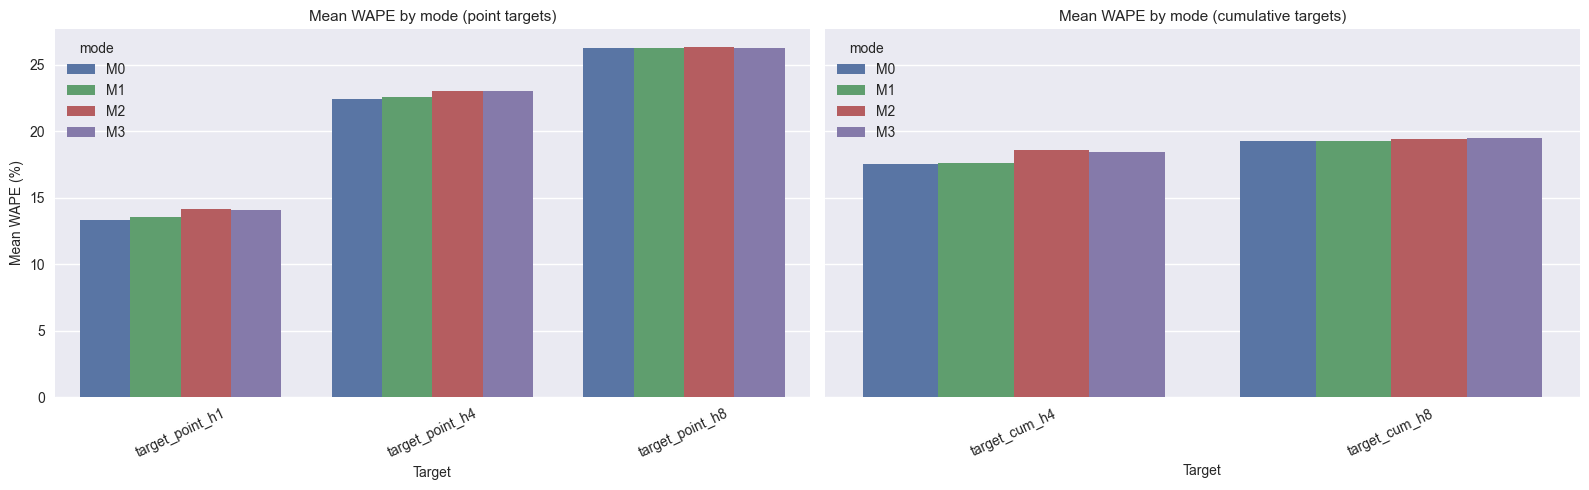

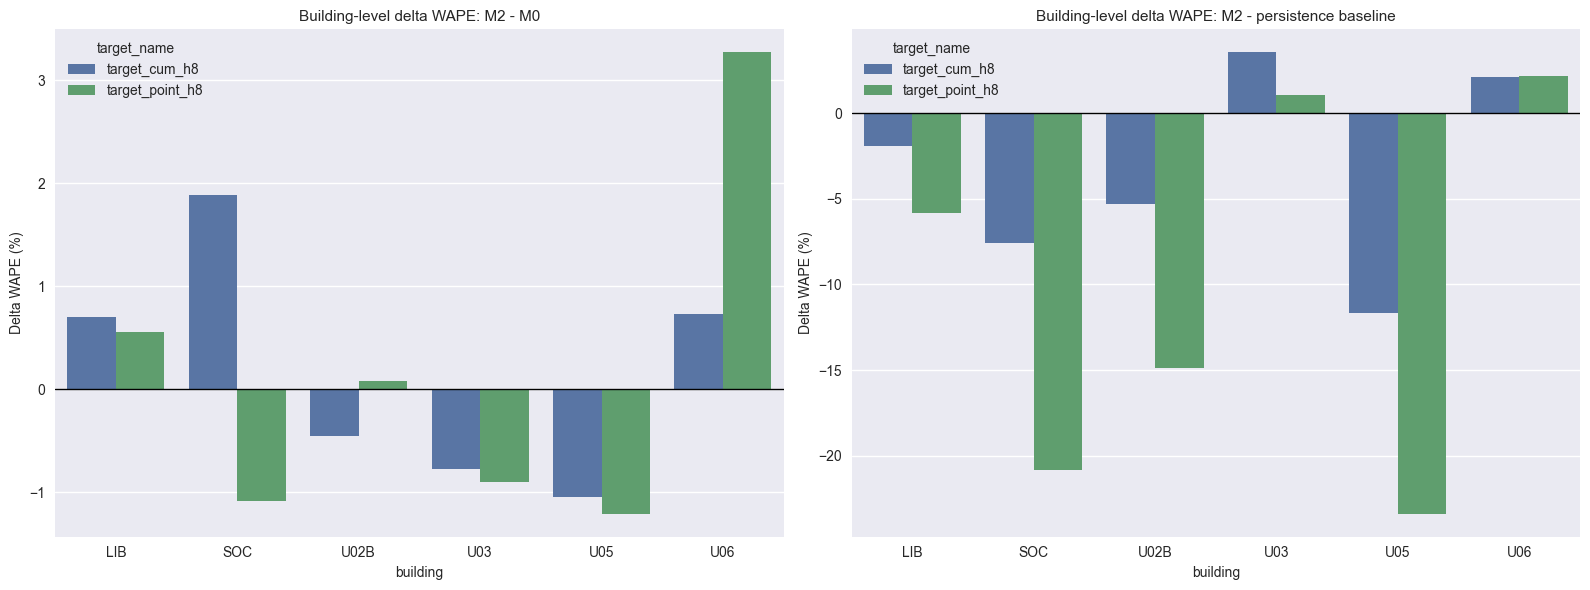

In [7]:
# Section 6 - Summaries, gains, and clean plots

from scipy import stats


def mean_ci95(x: pd.Series) -> Tuple[float, float, float]:
    arr = pd.Series(x).dropna().astype(float).to_numpy()
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    mean = float(arr.mean())
    if len(arr) == 1:
        return mean, mean, mean
    lo, hi = stats.t.interval(0.95, len(arr) - 1, loc=mean, scale=stats.sem(arr))
    return mean, float(lo), float(hi)


if long_run_log_df.empty:
    print('No long-horizon run log available yet.')
else:
    ok_df = long_run_log_df.loc[long_run_log_df['status'] == 'ok'].copy()

    summary_rows = []
    for keys, sub in ok_df.groupby(['target_family', 'target_name', 'horizon_hours', 'mode'], observed=True):
        target_family, target_name, horizon_hours, mode = keys
        w_mean, w_lo, w_hi = mean_ci95(sub['wape_pct'])
        b_mean, b_lo, b_hi = mean_ci95(sub['delta_wape_vs_baseline'])
        summary_rows.append({
            'target_family': target_family,
            'target_name': target_name,
            'horizon_hours': horizon_hours,
            'mode': mode,
            'n_runs': len(sub),
            'wape_mean': w_mean,
            'wape_ci95_low': w_lo,
            'wape_ci95_high': w_hi,
            'delta_vs_baseline_mean': b_mean,
            'delta_vs_baseline_ci95_low': b_lo,
            'delta_vs_baseline_ci95_high': b_hi,
            'mae_mean': float(sub['mae'].mean()),
            'rmse_mean': float(sub['rmse'].mean()),
            'r2_mean': float(sub['r2'].mean()),
            'baseline_wape_mean': float(sub['baseline_wape_pct'].mean()),
        })
    summary_df = pd.DataFrame(summary_rows).sort_values(['target_family', 'horizon_hours', 'mode']).reset_index(drop=True)

    gain_rows = []
    for (building, target_name), sub in ok_df.groupby(['building', 'target_name'], observed=True):
        spec = next(s for s in TARGET_SPECS if s['target_name'] == target_name)
        pivot = sub.groupby('mode', observed=True)['wape_pct'].mean().to_dict()
        base_pivot = sub.groupby('mode', observed=True)['baseline_wape_pct'].mean().to_dict()
        if 'M0' not in pivot:
            continue
        gain_rows.append({
            'building': building,
            'target_name': target_name,
            'target_family': spec['target_family'],
            'horizon_hours': spec['horizon_hours'],
            'baseline_wape_pct': float(np.mean(list(base_pivot.values()))) if base_pivot else np.nan,
            'M0': pivot.get('M0', np.nan),
            'M1': pivot.get('M1', np.nan),
            'M2': pivot.get('M2', np.nan),
            'M3': pivot.get('M3', np.nan),
            'delta_wape_M1_minus_M0': pivot.get('M1', np.nan) - pivot.get('M0', np.nan),
            'delta_wape_M2_minus_M0': pivot.get('M2', np.nan) - pivot.get('M0', np.nan),
            'delta_wape_M3_minus_M0': pivot.get('M3', np.nan) - pivot.get('M0', np.nan),
            'delta_wape_M2_minus_baseline': pivot.get('M2', np.nan) - float(np.mean(list(base_pivot.values()))) if base_pivot else np.nan,
            'delta_wape_M0_minus_baseline': pivot.get('M0', np.nan) - float(np.mean(list(base_pivot.values()))) if base_pivot else np.nan,
        })

    gain_df = pd.DataFrame(gain_rows)
    if not gain_df.empty:
        gain_df = gain_df.merge(
            proxy_df[['building_abv', 'vent_class', 'energy_class', 'ac24', 'night_day_ratio', 'n_vent_points']],
            left_on='building',
            right_on='building_abv',
            how='left',
        ).drop(columns=['building_abv'])

    display(summary_df)
    display(gain_df.sort_values(['target_family', 'horizon_hours', 'building']))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
    for ax, family in zip(axes, ['point', 'cumulative']):
        sub = summary_df.loc[summary_df['target_family'] == family].copy()
        order = sub[['target_name', 'horizon_hours']].drop_duplicates().sort_values('horizon_hours')['target_name'].tolist()
        sns.barplot(data=sub, x='target_name', y='wape_mean', hue='mode', order=order, ax=ax, errorbar=None)
        ax.set_title(f'Mean WAPE by mode ({family} targets)')
        ax.set_xlabel('Target')
        ax.set_ylabel('Mean WAPE (%)')
        ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

    if not gain_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        target_focus = gain_df[gain_df['target_name'].isin(['target_point_h8', 'target_cum_h8'])].copy()
        if not target_focus.empty:
            sns.barplot(data=target_focus, x='building', y='delta_wape_M2_minus_M0', hue='target_name', ax=axes[0], errorbar=None)
            axes[0].axhline(0.0, color='black', linewidth=1)
            axes[0].set_title('Building-level delta WAPE: M2 - M0')
            axes[0].set_ylabel('Delta WAPE (%)')

            sns.barplot(data=target_focus, x='building', y='delta_wape_M2_minus_baseline', hue='target_name', ax=axes[1], errorbar=None)
            axes[1].axhline(0.0, color='black', linewidth=1)
            axes[1].set_title('Building-level delta WAPE: M2 - persistence baseline')
            axes[1].set_ylabel('Delta WAPE (%)')
            plt.tight_layout()
            plt.show()


## Section 7 - Optional trace plot with seed ribbons

This section is optional and is meant for presentation-style plots.

It retrains the selected modes for one `building x target` combination and then plots:

- actual target
- mean prediction by mode across seeds
- a ribbon spanning the min/max prediction across seeds

This is not a formal confidence interval, but it is a useful stability band for presentation.


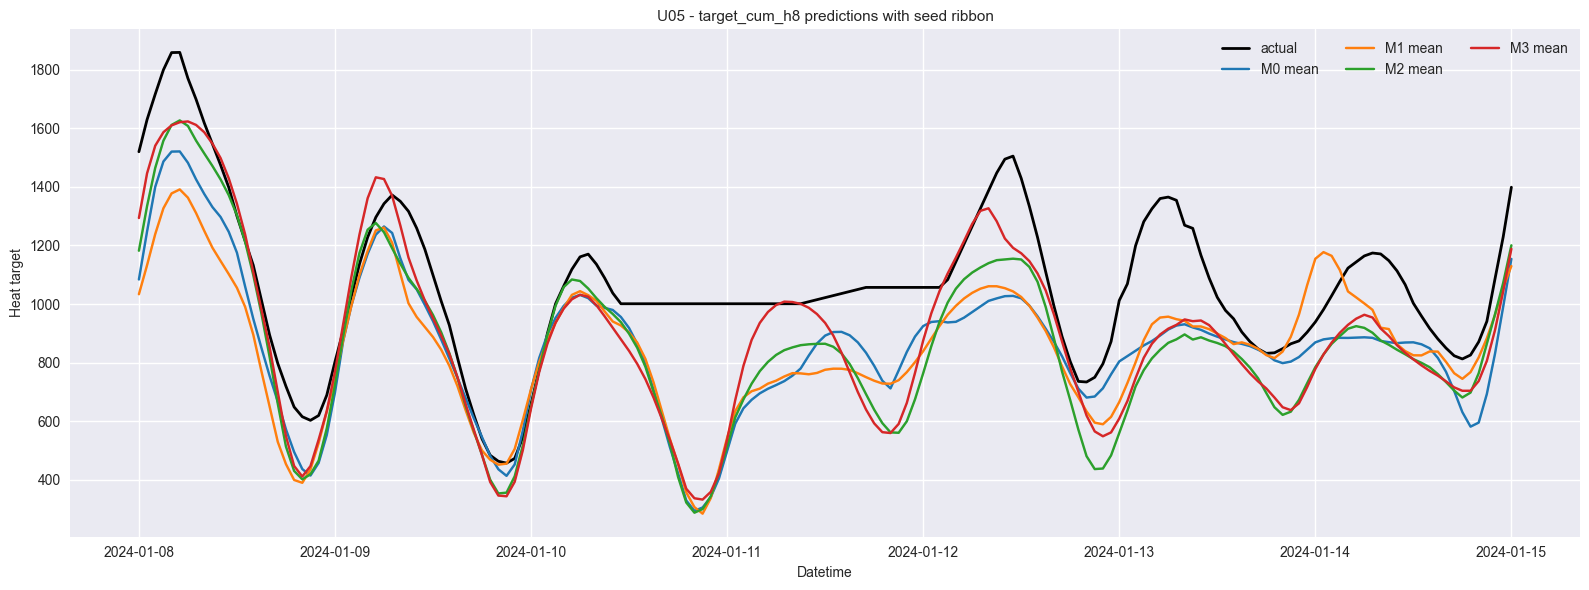

In [13]:
# Section 7 - Optional trace plot for one building/target
PLOT_TRACE_NOW = True

if PLOT_TRACE_NOW:
    spec = next(s for s in TARGET_SPECS if s['target_name'] == TRACE_TARGET)
    trace_frames = []
    for mode in RUN_MODES:
        for seed in RUN_SEEDS:
            trace_df = collect_trace_predictions(TRACE_BUILDING, spec, mode, seed)
            if not trace_df.empty:
                trace_frames.append(trace_df)

    if not trace_frames:
        print('No trace predictions available for the requested plot.')
    else:
        trace_all = pd.concat(trace_frames, ignore_index=True)
        trace_all.to_csv(TRACE_FILE, index=False)

        window = trace_all[(trace_all['datetime'] >= pd.Timestamp(TRACE_PLOT_START)) & (trace_all['datetime'] <= pd.Timestamp(TRACE_PLOT_END))].copy()
        summary = window.groupby(['datetime', 'mode'], observed=True).agg(
            y_true=('y_true', 'mean'),
            pred_mean=('y_pred', 'mean'),
            pred_min=('y_pred', 'min'),
            pred_max=('y_pred', 'max'),
        ).reset_index()

        plt.figure(figsize=(16, 6))
        actual = summary[['datetime', 'y_true']].drop_duplicates().sort_values('datetime')
        plt.plot(actual['datetime'], actual['y_true'], color='black', linewidth=2, label='actual')

        palette = {'M0': '#1f77b4', 'M1': '#ff7f0e', 'M2': '#2ca02c', 'M3': '#d62728'}
        for mode in RUN_MODES:
            sub = summary[summary['mode'] == mode].sort_values('datetime')
            if sub.empty:
                continue
            plt.plot(sub['datetime'], sub['pred_mean'], label=f'{mode} mean', color=palette.get(mode))
            plt.fill_between(sub['datetime'], sub['pred_min'], sub['pred_max'], color=palette.get(mode), alpha=0.15)

        plt.title(f'{TRACE_BUILDING} - {TRACE_TARGET} predictions with seed ribbon')
        plt.ylabel('Heat target')
        plt.xlabel('Datetime')
        plt.legend(ncol=3)
        plt.tight_layout()
        plt.show()
else:
    print('Trace plot skipped. Set PLOT_TRACE_NOW=True to generate a presentation-style plot.')


In [9]:
# Section 8 - Export tidy outputs

if long_run_log_df.empty:
    print('Nothing to export yet.')
else:
    ok_df = long_run_log_df.loc[long_run_log_df['status'] == 'ok'].copy()

    summary_rows = []
    for keys, sub in ok_df.groupby(['target_family', 'target_name', 'horizon_hours', 'mode'], observed=True):
        target_family, target_name, horizon_hours, mode = keys
        w_mean, w_lo, w_hi = mean_ci95(sub['wape_pct'])
        b_mean, b_lo, b_hi = mean_ci95(sub['delta_wape_vs_baseline'])
        summary_rows.append({
            'target_family': target_family,
            'target_name': target_name,
            'horizon_hours': horizon_hours,
            'mode': mode,
            'n_runs': len(sub),
            'wape_mean': w_mean,
            'wape_ci95_low': w_lo,
            'wape_ci95_high': w_hi,
            'delta_vs_baseline_mean': b_mean,
            'delta_vs_baseline_ci95_low': b_lo,
            'delta_vs_baseline_ci95_high': b_hi,
            'mae_mean': float(sub['mae'].mean()),
            'rmse_mean': float(sub['rmse'].mean()),
            'r2_mean': float(sub['r2'].mean()),
            'baseline_wape_mean': float(sub['baseline_wape_pct'].mean()),
        })
    summary_df = pd.DataFrame(summary_rows).sort_values(['target_family', 'horizon_hours', 'mode']).reset_index(drop=True)

    gain_rows = []
    for (building, target_name), sub in ok_df.groupby(['building', 'target_name'], observed=True):
        spec = next(s for s in TARGET_SPECS if s['target_name'] == target_name)
        pivot = sub.groupby('mode', observed=True)['wape_pct'].mean().to_dict()
        base_pivot = sub.groupby('mode', observed=True)['baseline_wape_pct'].mean().to_dict()
        if 'M0' not in pivot:
            continue
        gain_rows.append({
            'building': building,
            'target_name': target_name,
            'target_family': spec['target_family'],
            'horizon_hours': spec['horizon_hours'],
            'baseline_wape_pct': float(np.mean(list(base_pivot.values()))) if base_pivot else np.nan,
            'M0': pivot.get('M0', np.nan),
            'M1': pivot.get('M1', np.nan),
            'M2': pivot.get('M2', np.nan),
            'M3': pivot.get('M3', np.nan),
            'delta_wape_M1_minus_M0': pivot.get('M1', np.nan) - pivot.get('M0', np.nan),
            'delta_wape_M2_minus_M0': pivot.get('M2', np.nan) - pivot.get('M0', np.nan),
            'delta_wape_M3_minus_M0': pivot.get('M3', np.nan) - pivot.get('M0', np.nan),
            'delta_wape_M2_minus_baseline': pivot.get('M2', np.nan) - float(np.mean(list(base_pivot.values()))) if base_pivot else np.nan,
            'delta_wape_M0_minus_baseline': pivot.get('M0', np.nan) - float(np.mean(list(base_pivot.values()))) if base_pivot else np.nan,
        })
    gain_df = pd.DataFrame(gain_rows)
    if not gain_df.empty:
        gain_df = gain_df.merge(
            proxy_df[['building_abv', 'vent_class', 'energy_class', 'ac24', 'night_day_ratio', 'n_vent_points']],
            left_on='building',
            right_on='building_abv',
            how='left',
        ).drop(columns=['building_abv'])

    long_run_log_df.to_csv(RUNLOG_FILE, index=False)
    summary_df.to_csv(SUMMARY_FILE, index=False)
    gain_df.to_csv(GAIN_FILE, index=False)

    print('Saved:')
    print('-', RUNLOG_FILE)
    print('-', SUMMARY_FILE)
    print('-', GAIN_FILE)
    if TRACE_FILE.exists():
        print('-', TRACE_FILE)


Saved:
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/long_horizon_inertia_run_log.csv
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/long_horizon_inertia_summary.csv
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/long_horizon_inertia_gain_vs_M0.csv
- /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/long_horizon_inertia_trace_predictions.csv


## Section 9 - Building-specific inertia diagnostics

These plots are meant to answer the building-level question directly:

- where does the inertia-aware model `M2` improve on the plain LSTM `M0`?
- is that improvement stronger for `target_cum_h8` than for `target_point_h8`?
- are the gains associated with any simple building/system proxies?

These diagnostics use the exported long-horizon run log and are safe to rerun after the main matrix has finished.


,building,target_name,baseline_wape_pct,M0,M1,M2,M3,delta_wape_M1_minus_M0,delta_wape_M2_minus_M0,delta_wape_M3_minus_M0,delta_wape_M2_minus_baseline,delta_wape_M0_minus_baseline,vent_class,energy_class,ac24,night_day_ratio,n_vent_points
0,LIB,target_cum_h8,18.404475,15.804797,16.732996,16.503826,16.383072,0.928199,0.699029,0.578275,-1.900648,-2.599677,basic,NaN,0.836112,0.673699,1
2,SOC,target_cum_h8,29.070063,19.606466,19.645575,21.493254,19.291370,0.039108,1.886787,-0.315096,-7.576809,-9.463597,basic,NaN,0.779832,0.449909,2
4,U02B,target_cum_h8,30.282003,25.419340,24.769878,24.962448,23.881542,-0.649462,-0.456892,-1.537798,-5.319555,-4.862663,basic,NaN,0.802043,0.546111,1
6,U03,target_cum_h8,13.387519,17.718113,17.711203,16.947588,17.545918,-0.006910,-0.770525,-0.172195,3.560069,4.330594,rich,NaN,0.884472,0.700079,4
8,U05,target_cum_h8,32.278046,21.684546,21.411535,20.637188,22.368727,-0.273010,-1.047358,0.684181,-11.640858,-10.593500,basic,E,0.847695,0.485822,2
10,U06,target_cum_h8,13.802572,15.186831,15.257285,15.915441,17.639532,0.070454,0.728609,2.452701,2.112869,1.384260,basic,D,0.839260,0.743274,1
1,LIB,target_point_h8,29.198685,22.805569,22.644928,23.363398,21.845535,-0.160641,0.557829,-0.960033,-5.835287,-6.393116,basic,NaN,0.836112,0.673699,1
3,SOC,target_point_h8,47.666484,27.931162,27.912209,26.842386,26.083035,-0.018953,-1.088776,-1.848127,-20.824098,-19.735322,basic,NaN,0.779832,0.449909,2
5,U02B,target_point_h8,48.058998,33.090866,33.037071,33.172073,35.645809,-0.053795,0.081207,2.554943,-14.886925,-14.968132,basic,NaN,0.802043,0.546111,1
7,U03,target_point_h8,20.997299,22.996340,22.134737,22.094221,21.497507,-0.861603,-0.902119,-1.498833,1.096922,1.999041,rich,NaN,0.884472,0.700079,4


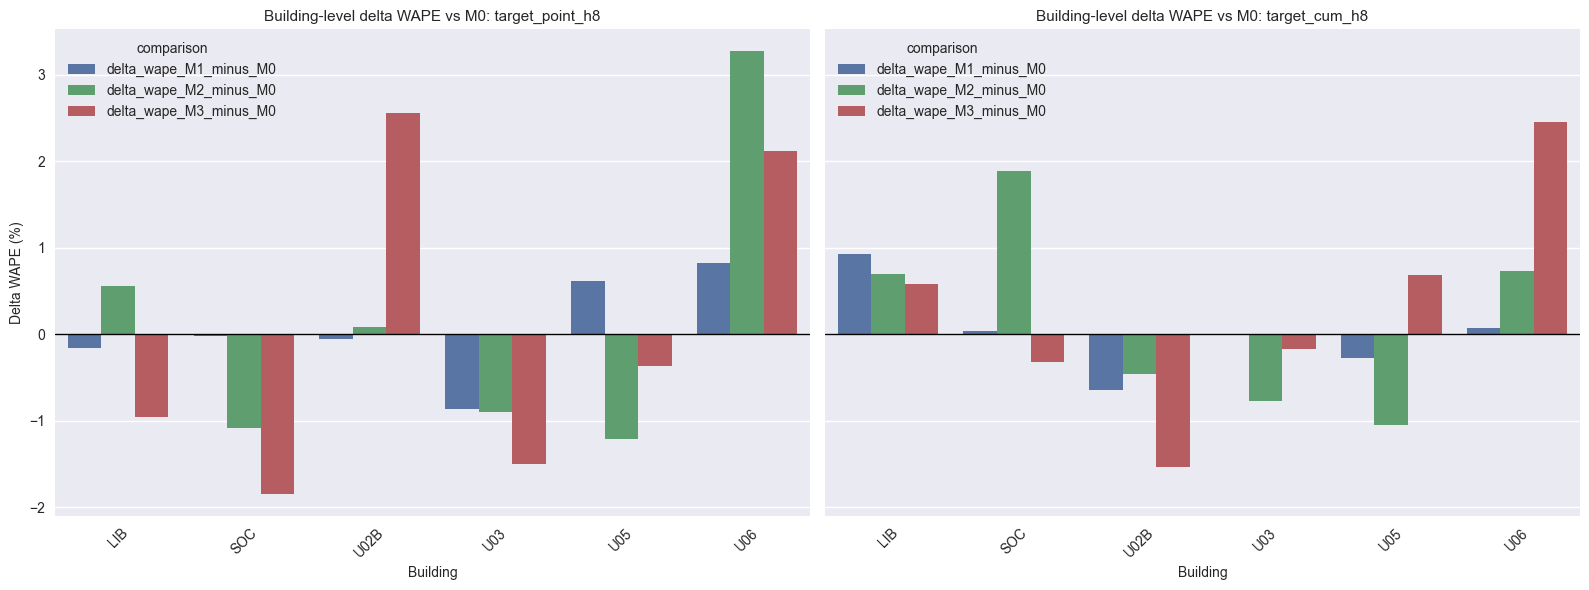

In [10]:
# Section 9 - Building-specific inertia diagnostics

DIAG_TARGETS = ['target_point_h8', 'target_cum_h8']
DIAG_MODES = ['M0', 'M1', 'M2', 'M3']

if not RUNLOG_FILE.exists() and not CHECKPOINT_FILE.exists():
    print('No long-horizon run log found yet.')
else:
    diag_source = RUNLOG_FILE if RUNLOG_FILE.exists() else CHECKPOINT_FILE
    diag_df = pd.read_csv(diag_source)
    diag_ok = diag_df.loc[diag_df['status'] == 'ok'].copy()
    diag_ok = diag_ok[diag_ok['target_name'].isin(DIAG_TARGETS)].copy()

    if diag_ok.empty:
        print('No matching completed rows for the requested diagnostic targets.')
    else:
        building_gain_rows = []
        for (building, target_name), sub in diag_ok.groupby(['building', 'target_name'], observed=True):
            piv = sub.groupby('mode', observed=True)['wape_pct'].mean().to_dict()
            base = float(sub['baseline_wape_pct'].mean())
            building_gain_rows.append({
                'building': building,
                'target_name': target_name,
                'baseline_wape_pct': base,
                'M0': piv.get('M0', np.nan),
                'M1': piv.get('M1', np.nan),
                'M2': piv.get('M2', np.nan),
                'M3': piv.get('M3', np.nan),
                'delta_wape_M1_minus_M0': piv.get('M1', np.nan) - piv.get('M0', np.nan),
                'delta_wape_M2_minus_M0': piv.get('M2', np.nan) - piv.get('M0', np.nan),
                'delta_wape_M3_minus_M0': piv.get('M3', np.nan) - piv.get('M0', np.nan),
                'delta_wape_M2_minus_baseline': piv.get('M2', np.nan) - base,
                'delta_wape_M0_minus_baseline': piv.get('M0', np.nan) - base,
            })

        diag_gain_df = pd.DataFrame(building_gain_rows)
        diag_gain_df = diag_gain_df.merge(
            proxy_df[['building_abv', 'vent_class', 'energy_class', 'ac24', 'night_day_ratio', 'n_vent_points']],
            left_on='building', right_on='building_abv', how='left'
        ).drop(columns=['building_abv'])

        display(diag_gain_df.sort_values(['target_name', 'building']))

        fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
        for ax, target_name in zip(axes, DIAG_TARGETS):
            sub = diag_gain_df[diag_gain_df['target_name'] == target_name].copy()
            long_sub = sub.melt(
                id_vars=['building'],
                value_vars=['delta_wape_M1_minus_M0', 'delta_wape_M2_minus_M0', 'delta_wape_M3_minus_M0'],
                var_name='comparison',
                value_name='delta_wape'
            )
            sns.barplot(data=long_sub, x='building', y='delta_wape', hue='comparison', ax=ax, errorbar=None)
            ax.axhline(0.0, color='black', linewidth=1)
            ax.set_title(f'Building-level delta WAPE vs M0: {target_name}')
            ax.set_ylabel('Delta WAPE (%)')
            ax.set_xlabel('Building')
            ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()


## Section 10 - Winter-week trace comparison

This section creates presentation-style plots for a selected building and target.

The plot shows:

- actual target
- `M0` mean prediction across seeds
- `M2` mean prediction across seeds
- seed ribbons (`min` to `max`) for each mode

That makes it easier to show whether the inertia-aware model changes the forecast shape in a meaningful way, even when the average portfolio metric difference is small.


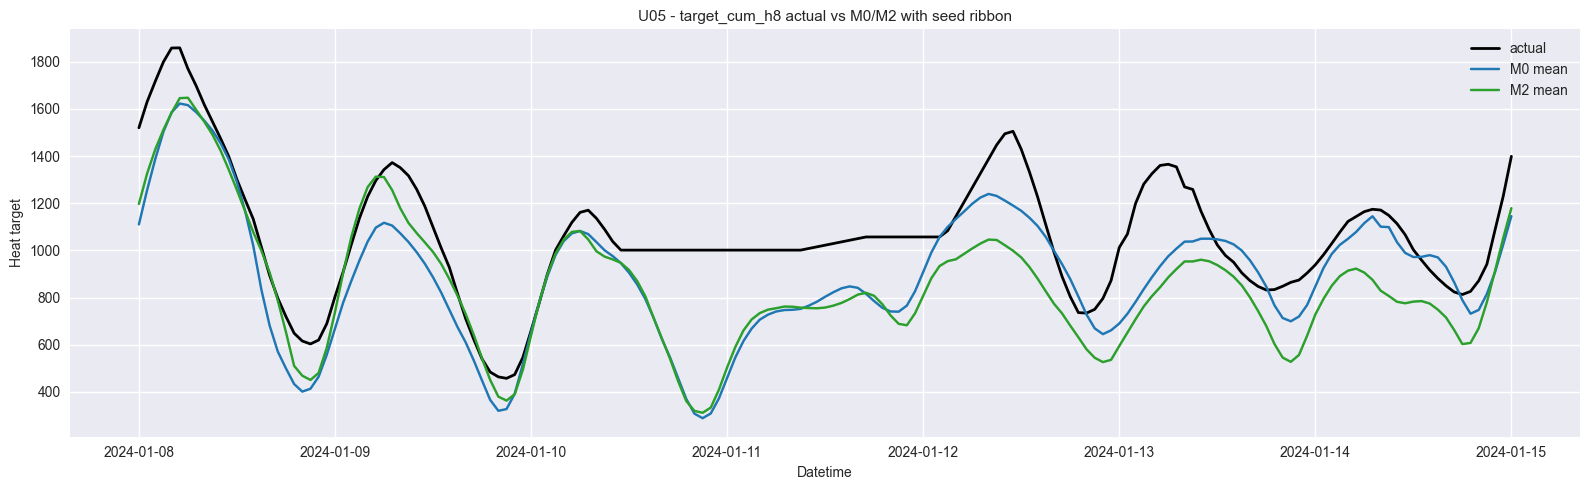

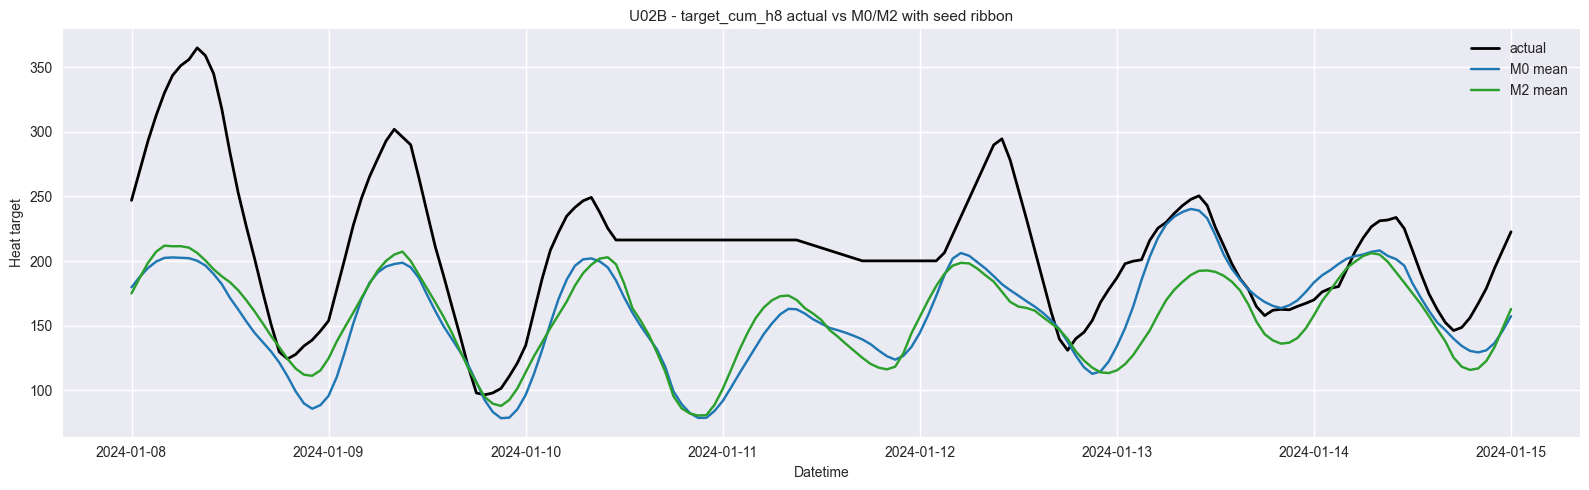

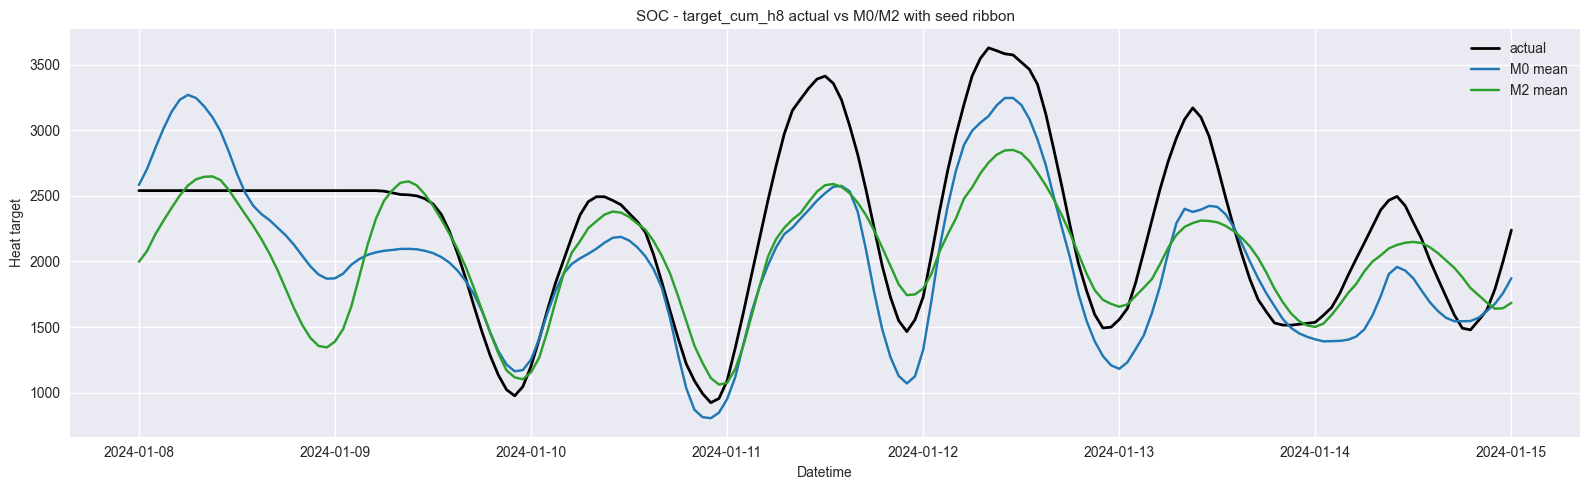

In [14]:
# Section 10 - Winter-week trace comparison

TRACE_DIAG_BUILDINGS = ['U05', 'U02B', 'SOC']
TRACE_DIAG_TARGET = 'target_cum_h8'
TRACE_COMPARE_MODES = ['M0', 'M2']
TRACE_WINDOW_START = '2024-01-08'
TRACE_WINDOW_END = '2024-01-15'
RUN_TRACE_DIAGNOSTICS_NOW = True

if RUN_TRACE_DIAGNOSTICS_NOW:
    spec = next(s for s in TARGET_SPECS if s['target_name'] == TRACE_DIAG_TARGET)
    all_trace_frames = []
    for building in TRACE_DIAG_BUILDINGS:
        for mode in TRACE_COMPARE_MODES:
            for seed in RUN_SEEDS:
                trace_df = collect_trace_predictions(building, spec, mode, seed)
                if not trace_df.empty:
                    all_trace_frames.append(trace_df)

    if not all_trace_frames:
        print('No trace predictions were generated.')
    else:
        trace_diag_df = pd.concat(all_trace_frames, ignore_index=True)
        trace_diag_df['datetime'] = pd.to_datetime(trace_diag_df['datetime'])
        trace_diag_df = trace_diag_df[
            (trace_diag_df['datetime'] >= pd.Timestamp(TRACE_WINDOW_START)) &
            (trace_diag_df['datetime'] <= pd.Timestamp(TRACE_WINDOW_END))
        ].copy()

        for building in TRACE_DIAG_BUILDINGS:
            sub = trace_diag_df[trace_diag_df['building'] == building].copy()
            if sub.empty:
                continue
            summary = sub.groupby(['datetime', 'mode'], observed=True).agg(
                y_true=('y_true', 'mean'),
                pred_mean=('y_pred', 'mean'),
                pred_min=('y_pred', 'min'),
                pred_max=('y_pred', 'max'),
            ).reset_index()
            actual = summary[['datetime', 'y_true']].drop_duplicates().sort_values('datetime')

            plt.figure(figsize=(16, 5))
            plt.plot(actual['datetime'], actual['y_true'], color='black', linewidth=2, label='actual')
            palette = {'M0': '#1f77b4', 'M2': '#2ca02c'}
            for mode in TRACE_COMPARE_MODES:
                sm = summary[summary['mode'] == mode].sort_values('datetime')
                if sm.empty:
                    continue
                plt.plot(sm['datetime'], sm['pred_mean'], color=palette[mode], label=f'{mode} mean')
                plt.fill_between(sm['datetime'], sm['pred_min'], sm['pred_max'], color=palette[mode], alpha=0.15)
            plt.title(f'{building} - {TRACE_DIAG_TARGET} actual vs M0/M2 with seed ribbon')
            plt.ylabel('Heat target')
            plt.xlabel('Datetime')
            plt.legend()
            plt.tight_layout()
            plt.show()
else:
    print('Trace diagnostics skipped. Set RUN_TRACE_DIAGNOSTICS_NOW=True to generate winter-week comparison plots.')


## Section 11 - Gain vs proxy scatter plots

These plots are meant for interpretation rather than proof.

They help answer questions like:

- do buildings with higher `ac24` benefit more from the inertia-aware block?
- is the gain related to night/day ratio or ventilation-point count?

With a small building set, these are descriptive, but they are often useful for thesis discussion.


,building,M0,M2,delta_wape_M2_minus_M0,vent_class,energy_class,ac24,night_day_ratio,n_vent_points
4,U05,21.684546,20.637188,-1.047358,basic,E,0.847695,0.485822,2
3,U03,17.718113,16.947588,-0.770525,rich,NaN,0.884472,0.700079,4
2,U02B,25.419340,24.962448,-0.456892,basic,NaN,0.802043,0.546111,1
0,LIB,15.804797,16.503826,0.699029,basic,NaN,0.836112,0.673699,1
5,U06,15.186831,15.915441,0.728609,basic,D,0.839260,0.743274,1
1,SOC,19.606466,21.493254,1.886787,basic,NaN,0.779832,0.449909,2


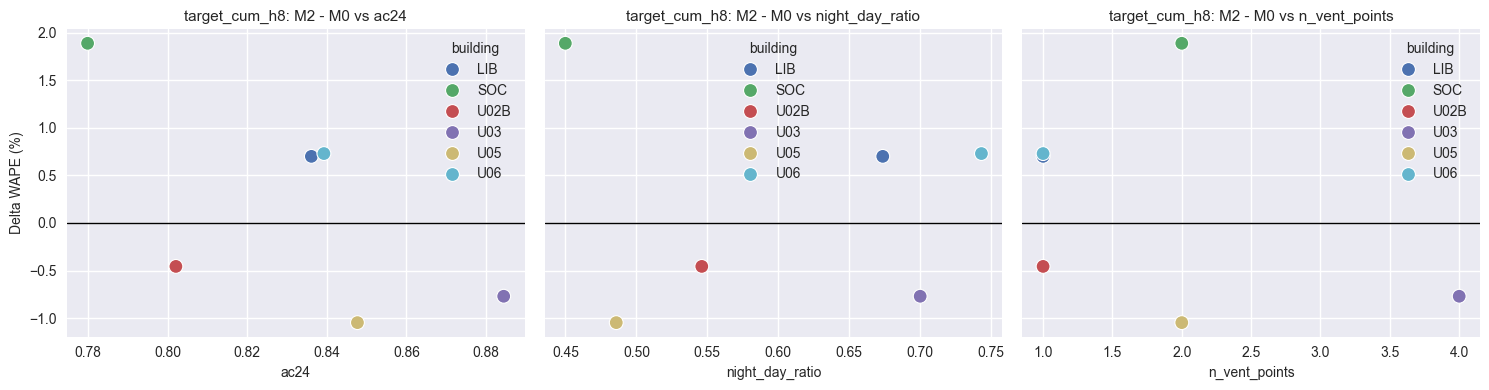

In [12]:
# Section 11 - Gain vs proxy scatter plots

PROXY_TARGET = 'target_cum_h8'
PROXY_X_COLS = ['ac24', 'night_day_ratio', 'n_vent_points']

if not RUNLOG_FILE.exists() and not CHECKPOINT_FILE.exists():
    print('No run log found for proxy diagnostics.')
else:
    diag_source = RUNLOG_FILE if RUNLOG_FILE.exists() else CHECKPOINT_FILE
    proxy_run_df = pd.read_csv(diag_source)
    proxy_ok = proxy_run_df[(proxy_run_df['status'] == 'ok') & (proxy_run_df['target_name'] == PROXY_TARGET)].copy()

    if proxy_ok.empty:
        print('No completed rows for proxy diagnostic target.')
    else:
        rows = []
        for building, sub in proxy_ok.groupby('building', observed=True):
            piv = sub.groupby('mode', observed=True)['wape_pct'].mean().to_dict()
            if 'M0' not in piv or 'M2' not in piv:
                continue
            rows.append({
                'building': building,
                'M0': piv.get('M0', np.nan),
                'M2': piv.get('M2', np.nan),
                'delta_wape_M2_minus_M0': piv.get('M2', np.nan) - piv.get('M0', np.nan),
            })
        proxy_gain_df = pd.DataFrame(rows)
        proxy_gain_df = proxy_gain_df.merge(
            proxy_df[['building_abv', 'vent_class', 'energy_class', 'ac24', 'night_day_ratio', 'n_vent_points']],
            left_on='building', right_on='building_abv', how='left'
        ).drop(columns=['building_abv'])
        display(proxy_gain_df.sort_values('delta_wape_M2_minus_M0'))

        fig, axes = plt.subplots(1, len(PROXY_X_COLS), figsize=(5 * len(PROXY_X_COLS), 4), sharey=True)
        if len(PROXY_X_COLS) == 1:
            axes = [axes]
        for ax, col in zip(axes, PROXY_X_COLS):
            sns.scatterplot(data=proxy_gain_df, x=col, y='delta_wape_M2_minus_M0', hue='building', s=100, ax=ax)
            ax.axhline(0.0, color='black', linewidth=1)
            ax.set_title(f'{PROXY_TARGET}: M2 - M0 vs {col}')
            ax.set_ylabel('Delta WAPE (%)')
        plt.tight_layout()
        plt.show()
